# Joint Co-Recall by Lag

> Estimate how often two study positions are both recalled on the same trial.

Co-recall by lag (CoRec) estimates the probability that two study positions separated by lag $d$ are both recalled on the same trial, ignoring recall order. For each positive lag, the analysis counts the number of co-recalled pairs and divides by the total number of pairs at that lag.

$$\text{CoRec}(d) = \frac{\sum_t \text{co-recalled pairs at lag } d}{\sum_t \text{possible pairs at lag } d}$$

Unlike conditional co-recall, the denominator here is the total number of possible pairs at each lag regardless of whether the anchor was recalled. This makes CoRec a joint probability measure rather than a conditional one.

## Workflow

In [1]:
import os
import matplotlib.pyplot as plt
import warnings
from jaxcmr.analyses.joint_corec_by_lag import plot_corec_by_lag
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data, save_figure

warnings.filterwarnings("ignore")

In [2]:
data_path = "data/HealeyKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
trial_query = "data['listtype'] == -1"
max_lag = None
confidence_level = 0.95

In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)

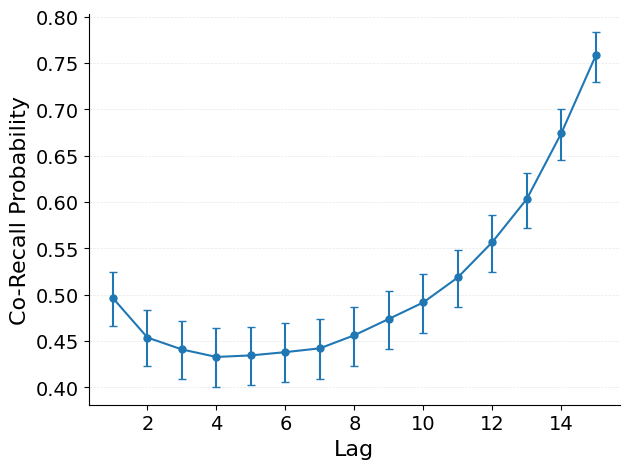

In [4]:
plot_corec_by_lag(datasets=data, trial_masks=trial_mask, max_lag=max_lag, confidence_level=confidence_level)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)

## Interpretation

The x-axis shows study lag and the y-axis shows the joint probability that both positions were recalled. Key patterns:

- **Declining with lag**: nearby study positions are more likely to be co-recalled, reflecting temporal clustering.
- **Comparison with conditional co-recall**: joint co-recall reflects both baseline recall rates and associative clustering, making it sensitive to overall recall level.

## API Details

### Notebook parameters

- `data_path` — path to an HDF5 file containing a `RecallDataset`.
- `figure_dir` — directory for saving figures.
- `figure_str` — base filename for the saved figure. Leave empty to display without saving.
- `ylim` — y-axis limits as a tuple, or `None` for automatic scaling.
- `trial_query` — a Python expression evaluated against the dataset to select trials.
- `max_lag` — maximum lag to display, or `None` to use all available lags.
- `confidence_level` — confidence level for subject-wise error bars.

To compare across datasets, re-run with different `data_path` and `trial_query` values. For example, `LohnasKahana2014.h5` uses `trial_query = "data['list_type'] == 1"` and `ylim = [.1, .26]`, while `HealeyKahana2014.h5` uses `trial_query = "data['listtype'] == -1"` and `ylim = [.1, .53]`.